<a href="https://colab.research.google.com/github/josi1219/gdsc_study_session_ML_g1/blob/main/Fake_news_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
from google.colab import files
uploaded = files.upload()

Saving Fake.csv to Fake.csv
Saving True.csv to True.csv


In [110]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


import tensorflow as tf
from tensorflow.keras import models, layers

**Importing Data**

I did not use the rest of the features in the data because we were instructed to work with dataset with only 1 feature (text) and label only. But in real scenarios, using them would increase the accuracy of the model

In [111]:

real = pd.read_csv("True.csv", usecols=[0])
fake = pd.read_csv("Fake.csv", usecols=[0])

real.columns = ['text']
fake.columns = ['text']

real['label'] = 0
fake['label'] = 1


data = pd.concat([real, fake], ignore_index=True)
data.to_csv("fake_news.csv", index=False)

data.head(5)

,text,label
0,"As U.S. budget fight looms, Republicans flip t...",0
1,U.S. military to accept transgender recruits o...,0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,0
3,FBI Russia probe helped by Australian diplomat...,0
4,Trump wants Postal Service to charge 'much mor...,0


In [112]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    44898 non-null  object
 1   label   44898 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 701.7+ KB


label
1    23481
0    21417
Name: count, dtype: int64


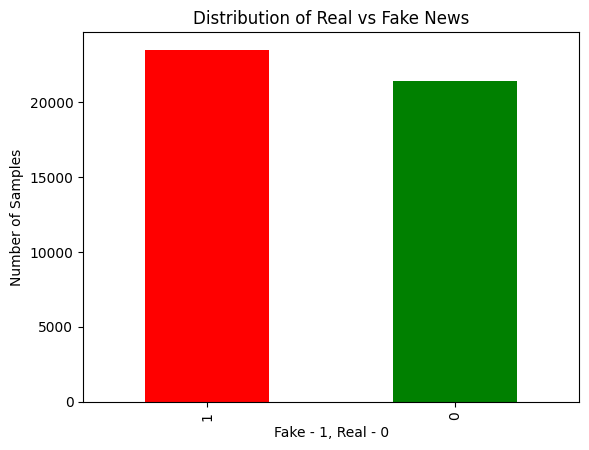

In [113]:

count = data['label'].value_counts()
print(count)

count.plot(kind='bar', color=['red', 'green'])
plt.title('Distribution of Real vs Fake News')
plt.xlabel('Fake - 1, Real - 0')
plt.ylabel('Number of Samples')
plt.show()

In [114]:
texts = data['text'].astype(str)
labels = data['label']

**Text Preprocessing**

In [115]:
vectorizer = TfidfVectorizer(max_features=5000)

In [116]:
X = vectorizer.fit_transform(texts).toarray()
y = labels.values

**Spliting the Dataset**

In [117]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Neural Network**

In [118]:
model = models.Sequential()

model.add(layers.Dense(128, activation='relu', input_shape=(5000,)))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Training the Model**

In [120]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)


Epoch 1/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.9338 - loss: 0.1735 - val_accuracy: 0.9571 - val_loss: 0.1137
Epoch 2/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9698 - loss: 0.0803 - val_accuracy: 0.9585 - val_loss: 0.1092
Epoch 3/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9827 - loss: 0.0466 - val_accuracy: 0.9591 - val_loss: 0.1202
Epoch 4/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9935 - loss: 0.0184 - val_accuracy: 0.9605 - val_loss: 0.1521
Epoch 5/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9983 - loss: 0.0058 - val_accuracy: 0.9605 - val_loss: 0.1937
Epoch 6/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.9995 - loss: 0.0018 - val_accuracy: 0.9568 - val_loss: 0.2248
Epoch 7/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.9998 - loss: 7.9094e-04 - val_accuracy: 0.9568 - val_loss: 0.2547
Epoch 8/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.99

**Evaluation of the Model**

In [121]:
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)
print("Test Loss:", loss)


281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9595 - loss: 0.3197

Test Accuracy: 0.959465503692627
Test Loss: 0.3197442889213562


**Prediction**

In [123]:
def predict_news(text):
    vec = vectorizer.transform([text]).toarray()
    pred = model.predict(vec)[0][0]

    confidence = pred * 100

    if pred > 0.5:
        print("Fake News")
        print("Confidence:", round(confidence, 2), "%")
    else:
        print("Real News")
        print("Confidence:", round(100 - confidence, 2), "%")

In [127]:
predict_news("Trump did 3 point shot on steph curry and started crying")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Fake News
Confidence: 100.0 %


In [126]:
predict_news("Bitcoin will likely drop 50% this year")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step
Real News
Confidence: 96.63 %


In [128]:
predict_news("Scientists confirm water on Mars.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Real News
Confidence: 99.78 %


In [129]:
predict_news("Scientists discover a new planet similar to Earth.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Real News
Confidence: 100.0 %


In [130]:
predict_news("Aliens have landed in New York and taken control of the city.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Fake News
Confidence: 100.0 %


**Answer to the questions asked**

I used a feedforward neural network with three layers. The first hidden layer has 128 neurons, the second hidden layer has 64 neurons, and the output layer has 1 neuron. The network was trained for up to 10 epochs. ReLU activation functions were used for the hidden layers, and a Sigmoid activation function was used for the output layer. The model achieved a test accuracy of 95.56%.